# ILUSTR 1 — Aliasing i rozdzielczość częstotliwościowa: dwa twarde ograniczenia DFT

Dyskretna transformata Fouriera nie "widzi" sygnału w pełni — widzi wyłącznie to, na co pozwala **sposób próbkowania**. Są dwa niezależne, twarde ograniczenia, które w praktyce sprawiają studentom najwięcej kłopotu:

1. **Aliasing** — częstotliwości powyżej połowy częstotliwości próbkowania ($f_s/2$, częstotliwość Nyquista) nie znikają — **przebierają się** za inną, niższą częstotliwość, nieodróżnialną w spróbkowanych danych.
2. **Rozdzielczość częstotliwościowa** — DFT z $N$ próbek dzieli widmo na "kubełki" (biny) co $\Delta f = f_s/N$. Dwie częstotliwości bliższe siebie niż $\Delta f$ zleją się w jeden pik, niezależnie od tego, jak dokładne są same próbki.

Oba ograniczenia pokażemy na konkretnych, policzalnych przykładach — bez żadnej teorii, którą trzeba by przyjąć na słowo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def widmo_amplitudowe(x, fs):
    # Zwraca (czestotliwosci, amplitudy) dla sygnalu rzeczywistego x probkowanego z czestotliwoscia fs.
    N = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    amp = np.abs(X) * 2 / N
    amp[0] /= 2                      # skladowa DC nie jest "podwojona" jak reszta widma
    if N % 2 == 0:
        amp[-1] /= 2                 # dla parzystego N czestotliwosc Nyquista tez nie jest podwojona
    return freqs, amp

# Sanity-check (dokladnie ten fakt, ktory slajd kursu podaje jako przyklad):
# sinusoida o amplitudzie 1 powinna dac w widmie pik o amplitudzie 1 (dzieki wspolczynnikowi skalowania 2/N).
t_test = np.arange(100) / 100.0
f_test, a_test = widmo_amplitudowe(np.cos(2*np.pi*5*t_test), fs=100)
print(f"Sanity-check: amplituda piku dla czystej sinusoidy = {a_test[np.argmax(a_test)]:.6f} (oczekiwane: 1.0)")

Sanity-check: amplituda piku dla czystej sinusoidy = 1.000000 (oczekiwane: 1.0)


## 1. Aliasing: częstotliwość "przebiera się" za inną

Weźmy sygnał $f(t)=\cos(2\pi\cdot45\cdot t)$ (prawdziwa częstotliwość 45 Hz) i spróbkujmy go z $f_s=50$ Hz. Częstotliwość Nyquista wynosi wtedy tylko $f_s/2=25$ Hz — 45 Hz jest daleko powyżej.

Prawdziwa czestotliwosc:  45.0 Hz
Czestotliwosc Nyquista:   25.0 Hz  (f0 jest powyzej -- aliasing gwarantowany)
Czestotliwosc aliasowa:   5.0 Hz


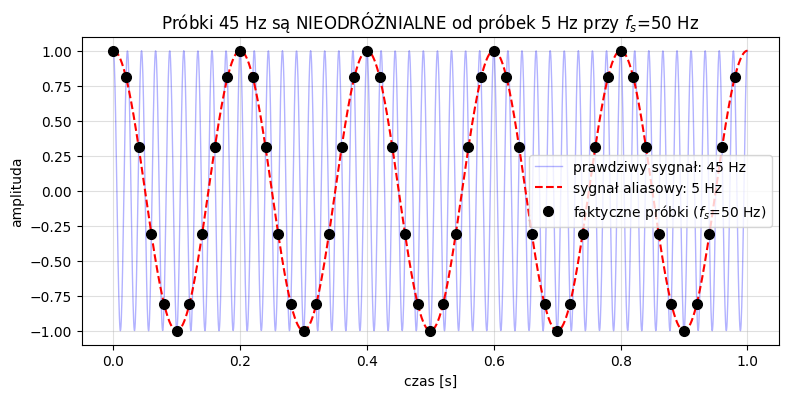

In [2]:
f0 = 45.0     # prawdziwa czestotliwosc sygnalu (Hz)
fs = 50.0     # czestotliwosc probkowania (Hz) -- ponizej wymaganych 2*f0=90 Hz!
czas_trwania = 1.0

n = np.arange(int(fs * czas_trwania))
próbki = np.cos(2 * np.pi * f0 * n / fs)

# Czestotliwosc "widmowa" (aliasowa), za ktora przebiera sie f0 przy tej fs:
f_alias = abs(f0 - round(f0 / fs) * fs)
print(f"Prawdziwa czestotliwosc:  {f0} Hz")
print(f"Czestotliwosc Nyquista:   {fs/2} Hz  (f0 jest powyzej -- aliasing gwarantowany)")
print(f"Czestotliwosc aliasowa:   {f_alias} Hz")

t_gesty = np.linspace(0, czas_trwania, 2000)   # gesta siatka czasu -- do narysowania "prawdziwego" przebiegu
t_probek = n / fs

plt.figure(figsize=(9, 4))
plt.plot(t_gesty, np.cos(2*np.pi*f0*t_gesty), 'b-', alpha=0.3, linewidth=1, label=f'prawdziwy sygnał: {f0:.0f} Hz')
plt.plot(t_gesty, np.cos(2*np.pi*f_alias*t_gesty), 'r--', linewidth=1.5, label=f'sygnał aliasowy: {f_alias:.0f} Hz')
plt.plot(t_probek, próbki, 'ko', markersize=7, label='faktyczne próbki ($f_s$=50 Hz)')
plt.xlabel('czas [s]')
plt.ylabel('amplituda')
plt.title('Próbki 45 Hz są NIEODRÓŻNIALNE od próbek 5 Hz przy $f_s$=50 Hz')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

Czarne punkty (faktyczne próbki) leżą **dokładnie** na obu krzywych naraz — niebieskiej (prawdziwej, 45 Hz) i czerwonej (aliasowej, 5 Hz). To nie jest przybliżenie: matematycznie $\cos(2\pi\cdot45\cdot n/50) \equiv \cos(2\pi\cdot5\cdot n/50)$ dla każdego całkowitego $n$, bo $45=50-5$, a próbkowanie "widzi" tylko fazę modulo pełny obrót. Żaden algorytm nie jest w stanie odróżnić tych dwóch sygnałów, mając wyłącznie próbki — to fundamentalne ograniczenie, nie wada konkretnej metody.

## 2. Rozdzielczość częstotliwościowa: DFT dzieli widmo na "kubełki" co $\Delta f = f_s/N$

Weźmy dwie bliskie sobie częstotliwości, $f_1=50$ Hz i $f_2=55$ Hz (różnica 5 Hz), próbkowane z $f_s=500$ Hz -- tym razem bez ryzyka aliasingu. Porównajmy **krótkie** i **długie** okno obserwacji.

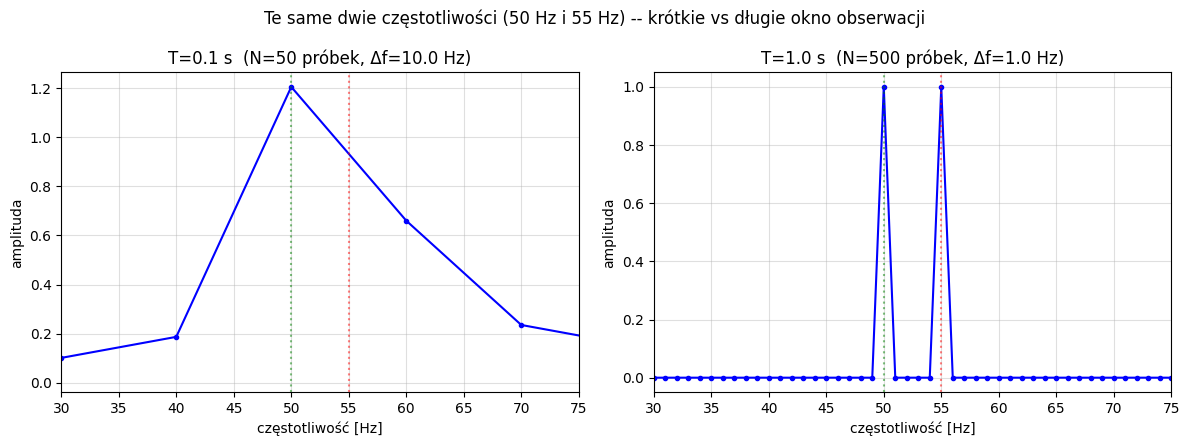

In [3]:
fs = 500.0
f1, f2 = 50.0, 55.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, T in zip(axes, [0.1, 1.0]):
    N = int(fs * T)
    n = np.arange(N)
    sygnal = np.cos(2*np.pi*f1*n/fs) + np.cos(2*np.pi*f2*n/fs)
    freqs, amp = widmo_amplitudowe(sygnal, fs)
    delta_f = fs / N
    ax.plot(freqs, amp, 'b-o', markersize=3)
    ax.set_xlim(30, 75)
    ax.set_xlabel('częstotliwość [Hz]')
    ax.set_ylabel('amplituda')
    ax.set_title(f'T={T} s  (N={N} próbek, Δf={delta_f:.1f} Hz)')
    ax.axvline(f1, color='g', linestyle=':', alpha=0.5)
    ax.axvline(f2, color='r', linestyle=':', alpha=0.5)
    ax.grid(True, alpha=0.4)

plt.suptitle('Te same dwie częstotliwości (50 Hz i 55 Hz) -- krótkie vs długie okno obserwacji')
plt.tight_layout()
plt.show()

Dla $T=0{,}1$ s rozdzielczość $\Delta f=10$ Hz jest **grubsza** niż odstęp między tonami (5 Hz) -- oba piki zlewają się w jeden garb. Dla $T=1$ s rozdzielczość $\Delta f=1$ Hz jest znacznie **drobniejsza** niż 5 Hz -- oba piki są wyraźnie rozdzielone. Kluczowy wniosek: **żadna** liczba próbek na sekundę (żadne zwiększanie $f_s$) tego nie naprawi -- liczy się wyłącznie **długość okna w czasie** $T=N/f_s$. To częsty błąd inżynierski: "dodam więcej próbek" zamiast "wydłużę pomiar".

## Najważniejsze wnioski

- Aliasing i rozdzielczość to **dwa niezależne** ograniczenia: pierwsze zależy tylko od $f_s$ (musi być $>2f_{max}$), drugie tylko od $T=N/f_s$ (musi być $>1/\Delta f_{potrzebne}$).
- Aliasing jest nieodwracalny na etapie próbkowania -- trzeba mu zapobiec *przed* próbkowaniem (filtr antyaliasingowy), nie da się go "naprawić" po fakcie analizując same próbki.
- Rozdzielczość częstotliwościowa nie poprawia się przez próbkowanie gęściej (większe $f_s$ przy tym samym $T$) -- tylko przez dłuższy pomiar (większe $T$).

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `np.fft.rfft(x)` | DFT sygnału rzeczywistego -- zwraca tylko nieujemne częstotliwości (druga połowa widma jest lustrzanym odbiciem) |
| `np.fft.rfftfreq(N, d)` | Oś częstotliwości odpowiadająca `rfft`, `d=1/fs` to odstęp między próbkami w czasie |
| `round(x)` | Zaokrąglenie do najbliższej liczby całkowitej -- używane we wzorze na częstotliwość aliasową |

## ĆWICZENIE

1. W przykładzie aliasingu zmień `f0` na 55 Hz (przy tym samym `fs=50`). Jaka będzie częstotliwość aliasowa? Sprawdź wzorem i na wykresie.
2. Znajdź najmniejsze $T$ (z dokładnością do 0,01 s), przy którym piki 50 Hz i 55 Hz z drugiej części zaczynają być wizualnie rozróżnialne jako dwa osobne maksima, a nie jeden garb. Porównaj z teoretycznym progiem $T\approx1/|f_1-f_2|$.
3. **Rozszerzenie na sygnał "czujnikowy"**: zbuduj syntetyczny sygnał przypominający dane z akcelerometru: `sygnal = cos(2*pi*3*t) + 0.3*cos(2*pi*12*t) + 0.5*cos(2*pi*50*t) + 0.1*szum` (3 Hz — ruch ciała, 12 Hz — wibracja mechaniczna, 50 Hz — zakłócenie sieciowe, plus szum). Dobierz `fs` i `T` tak, żeby rozróżnić wszystkie trzy składowe, i zidentyfikuj każdą z nich na widmie.